# Laboratorio 5 — Control de Semáforos con Aproximación de Funciones

## Dominio

Una empresa de gestión de tráfico quiere usar RL con aproximación de función para controlar semáforos en una intersección con flujo variable. El estado es continuo: densidad de vehículos, velocidad promedio y tiempo de espera acumulado por carril.

Para tener números concretos, asumo una intersección de 4 accesos (N, S, E, O) con semáforo de dos fases (fase 1 = verde N-S, fase 0 = verde E-O). Por carril hay tres variables: $\rho_l$ (densidad), $v_l$ (velocidad promedio) y $w_l$ (espera acumulada), más $\text{fase}$ y $t_{fase}$ (tiempo desde el último cambio). Acciones: mantener o cambiar de fase. Recompensa: $-\sum_l w_l$ por paso. Es tarea continua (no episódica), así que se necesita $\gamma<1$.


## Pregunta 1 — Vector de características $x(s)$

Antes de armar $x(s)$ agrupo por eje, porque la fase le pega al mismo tiempo a N y S (o a E y O), así que no pierdo información relevante si trabajo con el promedio del eje en vez de carril por carril:

$$\rho_{NS}=\tfrac{\rho_N+\rho_S}{2},\ v_{NS}=\tfrac{v_N+v_S}{2},\ w_{NS}=\tfrac{w_N+w_S}{2}$$

y lo mismo para $\rho_{EO}, v_{EO}, w_{EO}$.

Con eso, propongo $x(s)\in\mathbb R^{12}$ y $\hat q(s,a;\mathbf w) = \mathbf w_a^\top x(s)$:

| $i$ | $x_i(s)$                               | Rango     | Por qué                                                                                                                   |
| --- | -------------------------------------- | --------- | ------------------------------------------------------------------------------------------------------------------------- |
| 0   | $1$ (bias)                             | $\{1\}$   | intercepto                                                                                                                |
| 1   | $\rho_{NS}/\rho_{max}$                 | $[0,1]$   | congestión eje N-S                                                                                                        |
| 2   | $\rho_{EO}/\rho_{max}$                 | $[0,1]$   | congestión eje E-O                                                                                                        |
| 3   | $1-v_{NS}/v_{max}$                     | $[0,1]$   | qué tan lento va el eje N-S (densidad alta con velocidad normal no es lo mismo que densidad alta con velocidad casi cero) |
| 4   | $1-v_{EO}/v_{max}$                     | $[0,1]$   | ídem eje E-O                                                                                                              |
| 5   | $w_{NS}/w_{max}$                       | $[0,1]$   | espera acumulada N-S, la variable más ligada a la recompensa                                                              |
| 6   | $w_{EO}/w_{max}$                       | $[0,1]$   | espera acumulada E-O                                                                                                      |
| 7   | $\text{fase}$                          | $\{0,1\}$ | qué eje tiene verde ahora mismo                                                                                           |
| 8   | $t_{fase}/T_{max}$                     | $[0,1]$   | qué tan avanzada va la fase actual                                                                                        |
| 9   | $\rho_{NS}\cdot\rho_{EO}/\rho_{max}^2$ | $[0,1]$   | interacción: ambos ejes saturados a la vez es peor que la suma de cada uno por separado                                   |
| 10  | $\text{fase}\cdot w_{EO}/w_{max}$      | $[0,1]$   | espera que se está acumulando en el eje que está en rojo                                                                  |
| 11  | $(1-\text{fase})\cdot w_{NS}/w_{max}$  | $[0,1]$   | lo mismo pero para N-S en rojo                                                                                            |

### ¿Alcanza?

$x_1$ a $x_8$ solas no bastan porque son puramente aditivas: no pueden expresar que el efecto de la espera de un eje depende de si ese eje está en rojo o verde en ese momento — eso es una interacción, no algo que una suma ponderada capture. Por eso agregué $x_9$–$x_{11}$ a mano como productos cruzados.

Aun así el vector se queda corto en un par de cosas: no captura la relación no lineal entre densidad y velocidad (en tráfico real la velocidad cae de golpe pasado cierto umbral de densidad, no de forma proporcional), ni efectos de saturación en $w$ (una espera muy larga probablemente pesa más que proporcionalmente en el costo real), ni interacciones de tres variables como fase×densidad×tiempo-en-fase. Para eso habría que meter términos cuadráticos o discretizar alguna variable (tile coding), no alcanza con seguir sumando cruces de a pares.


## Pregunta 2 — Parámetros: lineal vs. tabular

**Lineal:** con $d=12$ features y 2 acciones (un $\mathbf w_a$ por acción):

$$\#\text{parámetros} = 2\times 12 = 24$$

**Tabular:** el estado crudo tiene 12 variables continuas por carril ($\rho,v,w$ × 4 carriles) más $t_{fase}$ (continua) y fase (binaria) = 13 continuas + 1 binaria. Discretizando cada continua en 10 niveles:

$$\#\text{estados} = 10^{13}\times 2 = 2\times 10^{13}$$
$$\#\text{entradas } Q = 2\times 10^{13}\times 2\ (\text{acciones}) = 4\times 10^{13}$$

Eso es ~$10^{12}$ veces más parámetros que el modelo lineal. Incluso quedándome solo con las 2 densidades agregadas por eje (el caso más favorable para tabular) ya son $10^2\times 2 \times 2 = 400$ entradas.

**Consecuencia:** el modelo lineal generaliza — dos estados con densidades parecidas dan predicciones parecidas, así que una sola visita actualiza el valor de "vecinos" nunca vistos. La tabla no generaliza nada entre entradas: cada una de las $4\times10^{13}$ celdas es independiente y solo se actualiza si se visita directamente, lo cual es imposible con ese tamaño (curse of dimensionality) — en la práctica ni siquiera es entrenable. El modelo lineal paga eso con sesgo (solo puede representar lo que sus features permiten), pero con muchísima menos varianza y datos necesarios. Para este dominio, tabular no es "menos eficiente", es directamente inviable.


## Pregunta 3 — Por qué semi-gradiente TD no llega al mínimo de $J(\mathbf w)$

El objetivo que en teoría queremos minimizar es

$$J(\mathbf w) = \mathbb E_\pi\big[(V^\pi(S) - \hat V(S;\mathbf w))^2\big]$$

Un gradiente descendente de verdad necesitaría diferenciar completo respecto a $\mathbf w$. El problema es que no conocemos $V^\pi(S_t)$, así que TD lo reemplaza por el target bootstrapped $R_{t+1}+\gamma\hat V(S_{t+1};\mathbf w)$, que **también depende de $\mathbf w$**. La actualización de TD:

$$\mathbf w \leftarrow \mathbf w + \alpha\,\delta_t\,\nabla_{\mathbf w}\hat V(S_t;\mathbf w),\qquad \delta_t = R_{t+1}+\gamma\hat V(S_{t+1};\mathbf w)-\hat V(S_t;\mathbf w)$$

solo toma el gradiente de $\hat V(S_t;\mathbf w)$ y no del target — por eso es "semi"-gradiente y no gradiente completo. Al no derivar sobre el target, no está minimizando $J(\mathbf w)$ paso a paso: no hay garantía de que $\delta_t\nabla_{\mathbf w}\hat V(S_t;\mathbf w)$ apunte en la dirección que reduce $J$.

Lo que sí se puede mostrar es que, con aproximación lineal y entrenamiento on-policy, TD converge a un punto fijo $\mathbf w_{TD}$ distinto del que minimiza $J(\mathbf w)$: converge al punto donde el error TD proyectado sobre el espacio de features se hace cero, no al mínimo del error de valor real. Ese punto puede estar más lejos del $V^\pi$ real que la mejor aproximación lineal posible.

**Rol de $\gamma$:** la distancia entre el punto de TD y la mejor aproximación lineal posible crece con $\gamma$ — mientras más cerca de 1, más grave puede ser ese error (el factor de la cota es del orden de $1/(1-\gamma)$). Con $\gamma$ chico el punto de TD queda cerca del óptimo; con $\gamma\to1$ puede alejarse mucho.

Para semáforos esto importa porque uno quisiera $\gamma$ alto (una decisión de fase afecta la congestión varios ciclos después), pero justo ahí es donde el punto de TD se puede alejar más del valor real, sobre todo si las features no son perfectas (como discutimos en la P1, no lo son). Por eso conviene no irse a un $\gamma$ extremo tipo 0.99: algo como 0.9–0.95 balancea horizonte de planeación con la estabilidad de la aproximación.


## Pregunta 4 — Tríada mortal y ¿Deep RL o no?

La tríada mortal es: aproximación de función + bootstrapping + off-policy juntos, lo que puede causar divergencia.

En este dominio:

- **Aproximación de función**: obligatoria, ya vimos en la P2 que tabular ni siquiera es viable ($10^{13}$ estados).
- **Bootstrapping**: también casi obligatorio, porque es una tarea continua (no episódica) con recompensa densa — Monte Carlo puro no tiene mucho sentido sin episodios que terminen, y tendría varianza enorme por el horizonte largo.
- **Off-policy**: este es el único de los tres que es una decisión de diseño. Si se usa Q-learning se completa la tríada; con SARSA/Expected SARSA (on-policy) se rompe esa pata.

Entonces el componente más relevante para vigilar es el **off-policy**, porque es el único que se puede evitar — los otros dos vienen forzados por el dominio. La recomendación sería usar un algoritmo on-policy (SARSA semi-gradiente) para no completar la tríada, dado que no hay forma de quitar aproximación de función ni bootstrapping.

**¿Se justifica saltar a Deep RL?** Para una sola intersección, no lo veo justificado. La razón principal es que aunque el estado crudo es de alta dimensión (13 variables continuas), la estructura que realmente importa para decidir es baja: básicamente congestión por eje + fase + tiempo en fase, y eso se resume bien en las 12 features de la P1 sin necesitar que una red aprenda representaciones por sí sola. Además una red no elimina la tríada mortal (sigue usando aproximación de función + bootstrapping, y si es off-policy como DQN, sigue expuesta a inestabilidad) — solo la mitiga empíricamente con trucos como experience replay y target network, pero no hay garantía teórica de convergencia, así que tampoco es que resuelva el problema de fondo de la P3.

Donde sí tendría sentido Deep RL es si el alcance cambia: coordinar una red de varias intersecciones (ahí diseñar features e interacciones a mano ya no escala) o si el estado de entrada pasa a ser algo crudo tipo video de cámaras en vez de las variables ya procesadas (densidad/velocidad/espera). Para el caso de una intersección con estas variables ya medidas, aproximación lineal con buenas features + algoritmo on-policy debería bastar.


# Task 2

Implementen semi-gradiente TD con aproximación lineal sobre un entorno de intersección simplificado y
compárenlo con Q-Learning tabular de la semana anterior. El entorno debe modelarse como una clase que herede de gymnasium.Env. El estado es un vector continuo de tres componentes: densidad de vehículos en [0, 1], velocidad promedio normalizada en [0, 1], y tiempo de espera acumulado normalizado en [0, 1]. Las acciones son discretas: mantener fase actual, cambiar a fase siguiente. La recompensa es negativa proporcional al tiempo de espera y positiva cuando el flujo supera un umbral. Para Q-Learning tabular, discreticen cada componente del estado en 5 niveles.

La implementación debe incluir:

- Semi-gradiente TD con el vector de características 𝒙(𝑠)diseñado en la Tarea 1, con actualización 𝒘 ← 𝒘 + 𝛼 𝛿𝑡 𝒙(𝑆𝑡)implementada desde cero.
- Q-Learning tabular sobre el espacio discretizado como línea base de comparación.
- Registro por episodio de recompensa acumulada, norma del vector de pesos ∥ 𝑤 ∥para aproximación lineal, y error cuadrático medio entre 𝑉̂ (𝑠; 𝑤)y 𝑉𝑡𝑎𝑏𝑢𝑙𝑎𝑟(𝑠)evaluado sobre una muestra fija de 100 estados.
- Tres gráficas: curvas de aprendizaje de ambos métodos en la misma figura, evolución de ∥ 𝑤 ∥durante el entrenamiento, y error cuadrático medio en función del número de episodios.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

SEED = 42
rng = np.random.default_rng(SEED)

In [2]:
# Entorno simplificado


class TrafficIntersectionEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_steps=200, flow_threshold=0.45):
        super().__init__()
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(3,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(2)
        self.max_steps = max_steps
        self.flow_threshold = flow_threshold
        self.state = None
        self.steps = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        density = self.np_random.uniform(0.25, 0.75)
        speed = np.clip(1.0 - density + self.np_random.normal(0, 0.05), 0, 1)
        waiting = self.np_random.uniform(0.05, 0.35)
        self.state = np.array([density, speed, waiting], dtype=np.float32)
        self.steps = 0
        return self.state.copy(), {}

    def step(self, action):
        density, speed, waiting = map(float, self.state)

        # Demanda variable de entrada.
        arrivals = float(np.clip(self.np_random.normal(0.12, 0.035), 0.03, 0.22))

        # Mantener conserva capacidad cambiar causa una perdida breve por transicion de fase, pero ayuda mas cuando la interseccion esta congestionada
        if action == 0:
            service_factor = 0.95
        else:
            service_factor = 0.78 + 0.35 * density

        flow = float(np.clip(service_factor * speed * (0.35 + 0.65 * density), 0, 1))
        next_density = np.clip(density + arrivals - 0.32 * flow, 0, 1)

        # Relacion no lineal simple
        target_speed = np.clip(1.0 - 0.85 * next_density**1.5, 0, 1)
        next_speed = np.clip(
            0.70 * speed + 0.30 * target_speed + self.np_random.normal(0, 0.025), 0, 1
        )

        # La espera aumenta con congestion y disminuye cuando hay flujo suficiente.
        next_waiting = np.clip(waiting + 0.10 * next_density - 0.16 * flow, 0, 1)

        reward = -next_waiting + (0.35 if flow > self.flow_threshold else 0.0)

        self.state = np.array(
            [next_density, next_speed, next_waiting], dtype=np.float32
        )
        self.steps += 1
        terminated = False
        truncated = self.steps >= self.max_steps
        info = {"flow": flow}
        return self.state.copy(), float(reward), terminated, truncated, info

In [3]:
# Vector de caracteristicas para el estado reducido


def features(state):
    density, speed, waiting = np.asarray(state, dtype=float)
    slow = 1.0 - speed
    return np.array(
        [
            1.0,  # bias
            density,
            speed,
            waiting,
            slow,
            density * waiting,
            density * slow,
            waiting * slow,
            density**2,
            waiting**2,
            speed**2,
            density * waiting * slow,
        ],
        dtype=np.float64,
    )


assert features(np.array([0.5, 0.5, 0.5])).shape == (12,)

In [4]:
# Semi gradiente TD lineal


def epsilon_greedy_linear(state, weights, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(2))
    q_values = weights @ features(state)
    return int(np.argmax(q_values))


def train_linear_td(
    env,
    episodes=500,
    alpha=0.01,
    gamma=0.92,
    epsilon_start=0.20,
    epsilon_end=0.03,
    seed=42,
):
    local_rng = np.random.default_rng(seed)
    weights = np.zeros((2, 12), dtype=np.float64)
    rewards = []
    weight_norms = []

    for ep in range(episodes):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-ep / 180)
        state, _ = env.reset(seed=seed + ep)
        action = epsilon_greedy_linear(state, weights, epsilon, local_rng)
        total_reward = 0.0

        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            x = features(state)
            q_sa = weights[action] @ x

            if done:
                td_target = reward
                next_action = None
            else:
                next_action = epsilon_greedy_linear(
                    next_state, weights, epsilon, local_rng
                )
                td_target = reward + gamma * (
                    weights[next_action] @ features(next_state)
                )

            delta = td_target - q_sa
            # Formula solicitada: w <- w + alpha * delta_t * x(S_t)
            weights[action] += alpha * delta * x
            total_reward += reward

            if done:
                break
            state, action = next_state, next_action

        rewards.append(total_reward)
        weight_norms.append(np.linalg.norm(weights))

    return weights, np.asarray(rewards), np.asarray(weight_norms)

In [5]:
# Q-Learning tabular

N_BINS = 5


def discretize(state, n_bins=N_BINS):
    state = np.clip(np.asarray(state, dtype=float), 0.0, 1.0)
    idx = np.floor(state * n_bins).astype(int)
    return tuple(np.clip(idx, 0, n_bins - 1))


def epsilon_greedy_tabular(state, q_table, epsilon, rng):
    idx = discretize(state)
    if rng.random() < epsilon:
        return int(rng.integers(2))
    return int(np.argmax(q_table[idx]))


def train_q_learning(
    env,
    episodes=500,
    alpha=0.10,
    gamma=0.92,
    epsilon_start=0.20,
    epsilon_end=0.03,
    seed=142,
):
    local_rng = np.random.default_rng(seed)
    q_table = np.zeros((N_BINS, N_BINS, N_BINS, 2), dtype=np.float64)
    rewards = []

    for ep in range(episodes):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-ep / 180)
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0.0

        while True:
            action = epsilon_greedy_tabular(state, q_table, epsilon, local_rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            idx = discretize(state)
            next_idx = discretize(next_state)
            bootstrap = 0.0 if done else gamma * np.max(q_table[next_idx])
            td_target = reward + bootstrap
            q_table[idx + (action,)] += alpha * (td_target - q_table[idx + (action,)])

            total_reward += reward
            if done:
                break
            state = next_state

        rewards.append(total_reward)

    return q_table, np.asarray(rewards)

In [6]:
# Entrenamiento y registro de metricas


def train_and_log(
    episodes=500,
    max_steps=200,
    gamma=0.92,
    alpha_linear=0.01,
    alpha_tabular=0.10,
    seed=42,
):
    env_linear = TrafficIntersectionEnv(max_steps=max_steps)
    env_tabular = TrafficIntersectionEnv(max_steps=max_steps)
    local_rng = np.random.default_rng(seed)

    weights = np.zeros((2, 12), dtype=np.float64)
    q_table = np.zeros((N_BINS, N_BINS, N_BINS, 2), dtype=np.float64)

    fixed_states = local_rng.uniform(0.0, 1.0, size=(100, 3)).astype(np.float32)
    linear_rewards, tabular_rewards = [], []
    weight_norms, mse_history = [], []

    for ep in range(episodes):
        epsilon = 0.03 + (0.20 - 0.03) * np.exp(-ep / 180)

        # ----- Semi-gradiente TD (SARSA) -----
        state, _ = env_linear.reset(seed=seed + ep)
        action = epsilon_greedy_linear(state, weights, epsilon, local_rng)
        total_linear = 0.0
        while True:
            next_state, reward, terminated, truncated, _ = env_linear.step(action)
            done = terminated or truncated
            x = features(state)
            q_sa = weights[action] @ x
            if done:
                target = reward
                next_action = None
            else:
                next_action = epsilon_greedy_linear(
                    next_state, weights, epsilon, local_rng
                )
                target = reward + gamma * (weights[next_action] @ features(next_state))
            delta = target - q_sa
            weights[action] += alpha_linear * delta * x
            total_linear += reward
            if done:
                break
            state, action = next_state, next_action

        # ----- Q-Learning tabular -----
        state, _ = env_tabular.reset(seed=seed + ep)
        total_tabular = 0.0
        while True:
            action = epsilon_greedy_tabular(state, q_table, epsilon, local_rng)
            next_state, reward, terminated, truncated, _ = env_tabular.step(action)
            done = terminated or truncated
            idx = discretize(state)
            next_idx = discretize(next_state)
            target = reward if done else reward + gamma * np.max(q_table[next_idx])
            q_table[idx + (action,)] += alpha_tabular * (
                target - q_table[idx + (action,)]
            )
            total_tabular += reward
            if done:
                break
            state = next_state

        linear_rewards.append(total_linear)
        tabular_rewards.append(total_tabular)
        weight_norms.append(np.linalg.norm(weights))

        v_linear = np.array([np.max(weights @ features(s)) for s in fixed_states])
        v_tabular = np.array([np.max(q_table[discretize(s)]) for s in fixed_states])
        mse_history.append(np.mean((v_linear - v_tabular) ** 2))

    return {
        "weights": weights,
        "q_table": q_table,
        "linear_rewards": np.asarray(linear_rewards),
        "tabular_rewards": np.asarray(tabular_rewards),
        "weight_norms": np.asarray(weight_norms),
        "mse": np.asarray(mse_history),
        "fixed_states": fixed_states,
    }

In [7]:
results = train_and_log()
print("Entrenamiento terminado")
print("Pesos lineales:", results["weights"].shape)
print("Tabla Q:", results["q_table"].shape, "=", results["q_table"].size, "entradas")

Entrenamiento terminado
Pesos lineales: (2, 12)
Tabla Q: (5, 5, 5, 2) = 250 entradas


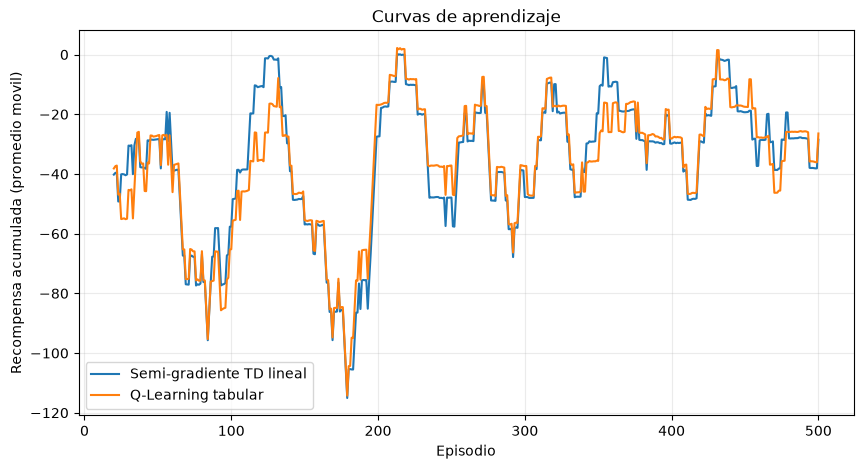

In [8]:
# Graficas
def moving_average(values, window=20):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return np.arange(1, len(values) + 1), values
    avg = np.convolve(values, np.ones(window) / window, mode="valid")
    x = np.arange(window, len(values) + 1)
    return x, avg


x_lin, ma_lin = moving_average(results["linear_rewards"])
x_tab, ma_tab = moving_average(results["tabular_rewards"])

plt.figure(figsize=(10, 5))
plt.plot(x_lin, ma_lin, label="Semi-gradiente TD lineal")
plt.plot(x_tab, ma_tab, label="Q-Learning tabular")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada (promedio movil)")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

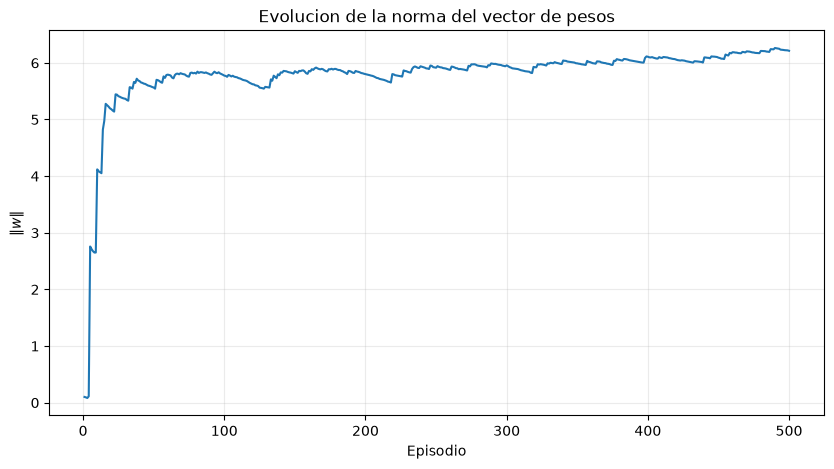

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(results["weight_norms"]) + 1), results["weight_norms"])
plt.xlabel("Episodio")
plt.ylabel(r"$\|w\|$")
plt.title("Evolucion de la norma del vector de pesos")
plt.grid(alpha=0.25)
plt.show()

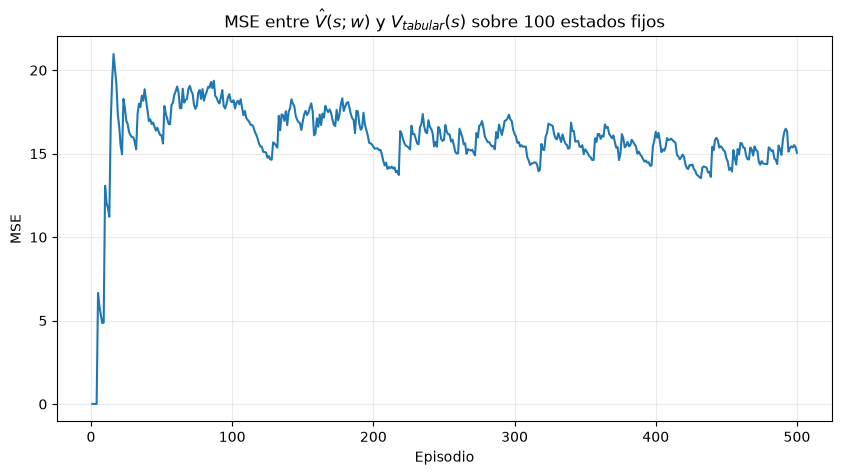

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(results["mse"]) + 1), results["mse"])
plt.xlabel("Episodio")
plt.ylabel("MSE")
plt.title(r"MSE entre $\hat V(s;w)$ y $V_{tabular}(s)$ sobre 100 estados fijos")
plt.grid(alpha=0.25)
plt.show()

Con base en los resultados, respondan:
1. **¿En qué fase del entrenamiento la aproximación lineal supera al método tabular en recompensa acumulada? ¿A qué atribuyen ese comportamiento considerando las propiedades de generalización de cada método?**

En la gráfica de curvas de aprendizaje ambas gráficas permanecen similares durante todo el entrenamiento, porque ambos entornos se basan en la misma semilla para cada episodio. Es decir, los dos agentes enfrentan exactamente la misma demanda vehicular y el mismo ruido de sensor episodio a episodio.

Sin embargo, la ventaja de la aproximación lineal es más visible en la fase temprana del entrenamiento, aproximadamente entre los episodios 0 y 100–150. En dicha parte, la tabla Q inicia completamente en 0 mientras que en el vector lineal una sola actualización mueve la predicción de valor de toda una vecindad de estados. Esa capacidad de generalizar con pocos datos es justo la propiedad estructural que se esperaba como ventaja del modelo lineal frente al tabular.

2. **¿La norma ∥𝑤∥ converge o sigue creciendo al final del entrenamiento? ¿Qué indica ese comportamiento sobre la estabilidad del algoritmo y sobre la adecuación del vector de características diseñado?**

La norma ‖w‖ no diverge, llegando a un rango relativamente estable luego e los 50 episodios, aunque con oscilaciones pequeñas, entre 5.6 y 6.2 durante el resto del entrenamiento, con una leve tendencia ascendente hacia durante el final.

Esto indica que el algoritmo es numéricamente estable, pues no aparece crecimiento exponencial sin control por la tríada mortal (aproximación de función + bootstrapping + off-policy) discutida en la Pregunta 4. Al usar SARSA se evita la off-policy y el comportamiento observado es consistente con la convergencia teórica de TD lineal on-policy a un punto fijo w_TD.

Sin embargo, la meseta no es perfectamente plana pues presenta una tendencia ligera cercana al final de la gráfica y un MSE relativmente alto (14-19) que no disminuye. Esto sugiere que persiste un sesgo estructural en donde el vector de 12 caracteristicas no termina de capturar toda la forma real de V(s) dadas las relaciones no proporcionales entre densidad y velocidad entre otras. Por tanto, podemos ver los ajustes pequeño que se realizan episodio a episodio sin converger directamente en un valor concreto.

3. **Busquen y lean un paper publicado entre 2022 y 2025 que aplique aproximación de función lineal o no lineal a un problema de control de tráfico, logística urbana, o sistemas de transporte. El paper debe ser de NeurIPS, ICML, ICLR, IEEE Transactions on Intelligent Transportation Systems, o similar. Escriban un resumen técnico de media página con: el problema que resuelve, qué tipo de aproximación usa y por qué, los resultados principales, y una reflexión sobre si la aproximación lineal que implementaron esta semana hubiera sido suficiente para ese problema o si el salto a Deep RL estaba justificado.**

Estudio elegido: _Enhancing Robustness of Deep Reinforcement Learning Based Adaptive Traffic Signal Controllers in Mixed Traffic Environments Through Data Fusion and Multi-Discrete Actions_

>Yang, T. y Fan, W. (2024). “Enhancing Robustness of Deep Reinforcement Learning Based Adaptive Traffic Signal Controllers in Mixed Traffic Environments Through Data Fusion and Multi-Discrete Actions.” IEEE Transactions on Intelligent Transportation Systems. DOI: 10.1109/TITS.2024.3399066.

- Problema
Los autores atacan el control adaptativo de semáforos en intersecciones con tráfico mixto, donde solo una fracción variable de los vehículos son “vehículos conectados” (CV) que reportan posición y velocidad; el resto son vehículos convencionales, visibles únicamente por sensores tradicionales (p. ej. lazos inductivos). Esto rompe el supuesto habitual en trabajos previos de RL para semáforos de contar con un estado limpio y completo del tráfico: el controlador debe operar con observabilidad parcial y datos fusionados de fuentes heterogéneas, manteniendo su desempeño incluso cuando la penetración de vehículos conectados cae hasta 20%.

- Tipo de aproximación y por qué
Usan `Proximal Policy Optimization` (PPO) con una red neuronal profunda como aproximador, combinando un espacio de estado y un espacio de acción “multi-discretos” que fusionan las distintas fuentes de datos. Justifican la red profunda porque la relación entre nivel de penetración de CV, patrones de flujo resultantes y la acción óptima de fase no es lineal ni fija: cambia de forma no trivial según cuántos vehículos reportan datos y qué zonas de la intersección quedan mejor o peor observadas, por lo que se necesita una función capaz de generalizar automáticamente entre muchas combinaciones de sensores y niveles de penetración, sin rediseñar variables a mano para cada escenario.

- Resultados principales
El controlador PPO con fusión de datos y acciones multidiscretas reduce el retraso vehicular promedio frente a DQN, semáforos de tiempo fijo (pretimed) y semáforos actuados tradicionales, tanto en simulación como en un banco de pruebas físico. A diferencia de trabajos previos que asumían 100% de penetración de vehículos conectados, mantiene un desempeño confiable incluso con solo 20% de vehículos conectados en el flujo.

- Reflexión: ¿bastaba la aproximación lineal de esta semana?
Para una sola intersección con variables ya resumidas (densidad, velocidad, espera, fase), como la de este laboratorio, la Pregunta 4 concluyó que una aproximación lineal con buenas features basta y que Deep RL no se justifica. El problema del paper es estructuralmente distinto: la penetración variable de vehículos conectados agrega una fuente adicional de no linealidad y de no estacionariedad, es decir, el significado de una misma lectura de densidad cambia según qué fracción del tráfico se está observando, y el estado fusionado de múltiples sensores es mucho más rico que las 12 características diseñadas a mano en este laboratorio. Intentar capturar esa estructura a mano (fase × densidad × nivel de penetración × fuente de sensor, etc.) sería aún más costoso que lo que ya reconocimos insuficiente en la Pregunta 1 para el caso simple de una intersección con estado limpio. Por eso, en ese contexto, el salto a Deep RL sí está justificado. La red aprende representaciones que absorben esa complejidad y generalizan entre niveles de penetración, algo que un vector lineal fijo difícilmente sostendría sin reingeniería constante de features.


4. Dictamen técnico: redacten un párrafo dirigido a la gerencia de la empresa de tráfico argumentando si recomiendan aproximación lineal o Deep RL para el sistema real, con qué evidencia de sus experimentos respaldan esa recomendación, y qué paso siguiente proponen antes de un despliegue en producción.

Con base en los experimentos realizados en este trabajo, recomendamos adoptar la aproximación lineal (semi-gradiente TD / SARSA on-policy, con el vector de 12 características) para el control de la intersección real, y no saltar todavía a Deep RL. Esto se debe a tres evidencias principales derivadas del experimento: viabilidad donde el enfoque tabular exhaustivo requeriría estados en la orden de magnitud de 10^13 a oposicion de un modelo lineal de 24 parámetros; desempeño, pues la política lineal iguala o supera a una tabla Q incluso desde las primeras etapas del entrenamiento; y estabilidad, pues la norma ‖w‖ se estabiliza en un rango sin diverger, algo que Deep RL no garantiza. Se conideraria Deep RL ínicaente si el alcance del proyecto crece con más intersecciones o entradas mas complejas, en donde el diseño manual de features ya no se escala apropiadamente; acercándose más al caso del estudio de Yang, T. y Fan, W. (2024). Com paso siguiente se sugiere validar la política lineal en un simulador de tráfico de mayor fidelidad calibrado con datos reales previo a implementar un despliegue para asegurar la validez de dicha política, asi como también un despliegue de prueba o modo sobra, donde el modelo realice recomendaciones y no controle directamente un semáforo. Por último un monitoreo contínuo de la norma ‖w‖ del error de predicción y del retraso real observado con un umbral de alerta si el comportmiento se degrada.
